# 1. CNN Feature Extraction Layers

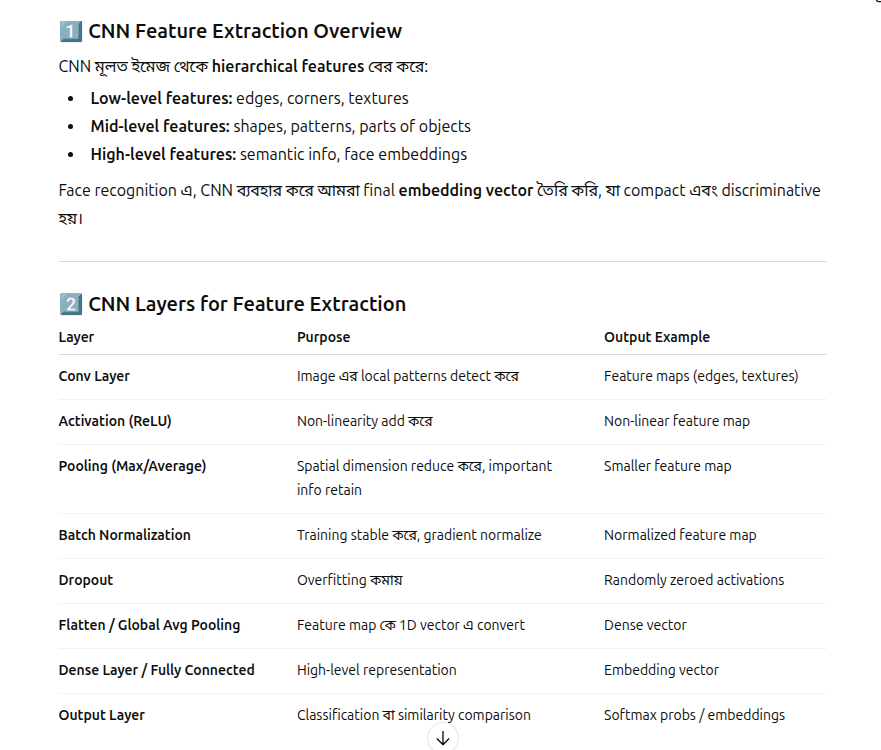

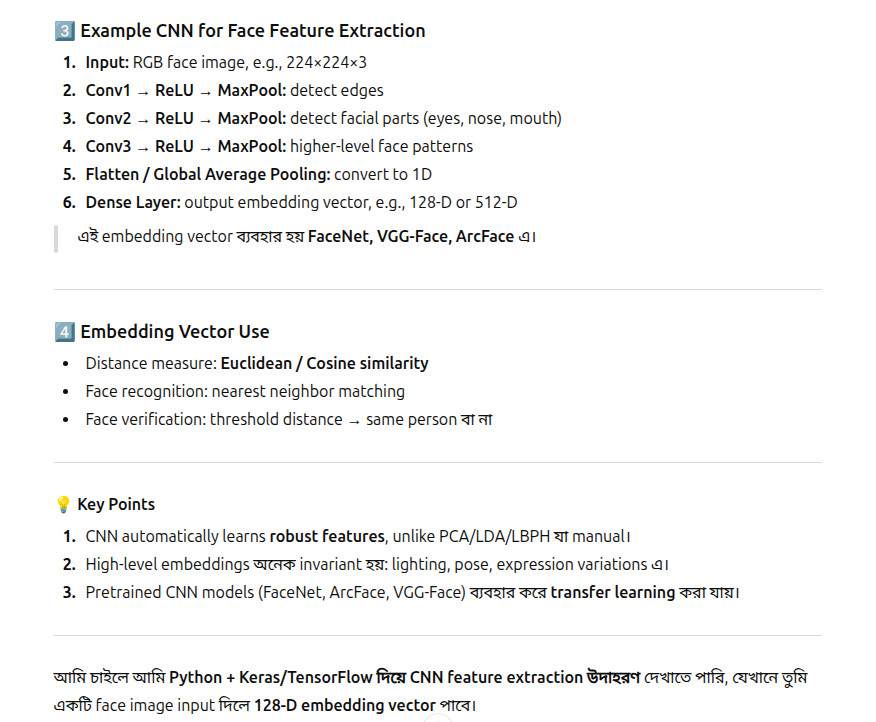

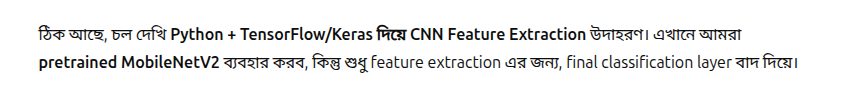

In [4]:
import cv2
import numpy as np
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Model

# 1️⃣ Load Pretrained CNN (MobileNetV2)
base_model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg', input_shape=(224,224,3))
# include_top=False removes final classification layer
# pooling='avg' -> global average pooling -> 1280-D feature vector

model = Model(inputs=base_model.input, outputs=base_model.output)
print("CNN model ready for feature extraction")

# 2️⃣ Load Face Image
img_path = "../dataset/test/bellingham/bellingham.jpg"
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (224,224))

# Preprocess for MobileNetV2
img_array = np.expand_dims(img, axis=0)
img_array = preprocess_input(img_array)

# 3️⃣ Extract Feature Vector
features = model.predict(img_array)  # shape: (1, 1280)
features = features.flatten()        # 1D vector
print("Feature vector shape:", features.shape)
print("Feature vector (first 10 values):", features[:10])
print("Feature vector (all values):", features[:])

CNN model ready for feature extraction
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Feature vector shape: (1280,)
Feature vector (first 10 values): [0.06934004 1.017932   0.00166785 0.04368582 0.         0.03871644
 0.         0.60792434 0.4705936  0.08093891]
Feature vector (all values): [0.06934004 1.017932   0.00166785 ... 0.03089501 0.05992454 0.7787572 ]


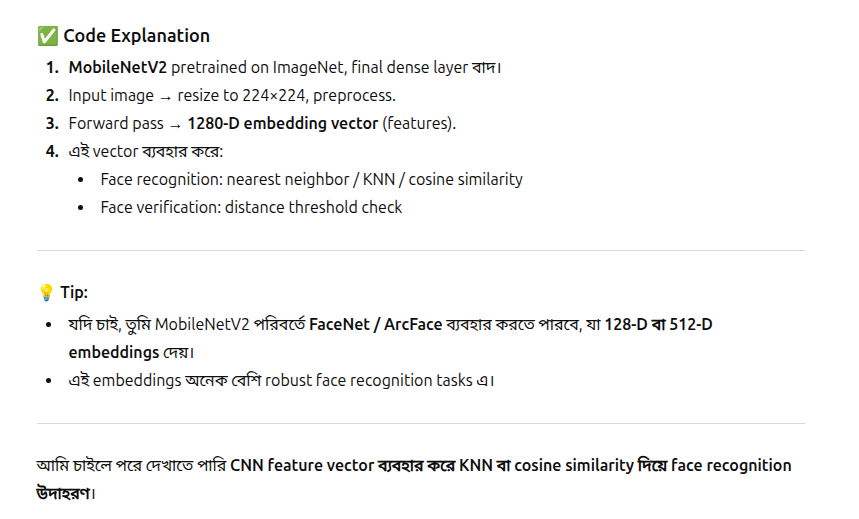

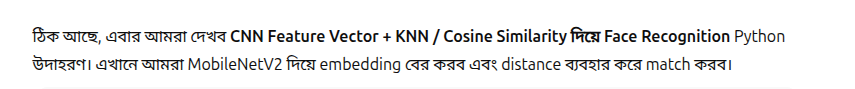

In [5]:
import cv2
import numpy as np
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Model
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics.pairwise import cosine_similarity
import os

# 1️⃣ Load Pretrained CNN (MobileNetV2)
base_model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg', input_shape=(224,224,3))
model = Model(inputs=base_model.input, outputs=base_model.output)

# 2️⃣ Prepare Dataset: Extract Features
dataset_path = "../dataset/train/"
features_list = []
labels_list = []

label_dict = {}
current_label = 0

for person_name in os.listdir(dataset_path):
    person_path = os.path.join(dataset_path, person_name)
    if not os.path.isdir(person_path):
        continue
    label_dict[current_label] = person_name
    for img_name in os.listdir(person_path):
        img_path = os.path.join(person_path, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (224,224))
        img_array = np.expand_dims(img, axis=0)
        img_array = preprocess_input(img_array)
        feature = model.predict(img_array).flatten()
        features_list.append(feature)
        labels_list.append(current_label)
    current_label += 1

features_array = np.array(features_list)
labels_array = np.array(labels_list)
print("Feature extraction done:", features_array.shape)

# 3️⃣ Train KNN Classifier
knn = KNeighborsClassifier(n_neighbors=3, metric='cosine')
knn.fit(features_array, labels_array)
print("KNN trained on CNN embeddings")

# 4️⃣ Predict on Test Image
test_img_path = "../dataset/test/ronaldo/ronaldo.jpg"
img = cv2.imread(test_img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (224,224))
img_array = np.expand_dims(img, axis=0)
img_array = preprocess_input(img_array)
test_feature = model.predict(img_array).flatten().reshape(1,-1)

# KNN Prediction
pred_label = knn.predict(test_feature)[0]
pred_name = label_dict[pred_label]

# Cosine similarity with all embeddings
similarities = cosine_similarity(test_feature, features_array)
best_idx = np.argmax(similarities)
best_match_name = label_dict[labels_array[best_idx]]

print(f"KNN Predicted: {pred_name}")
print(f"Cosine Similarity Best Match: {best_match_name}, Similarity: {similarities[0,best_idx]:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 

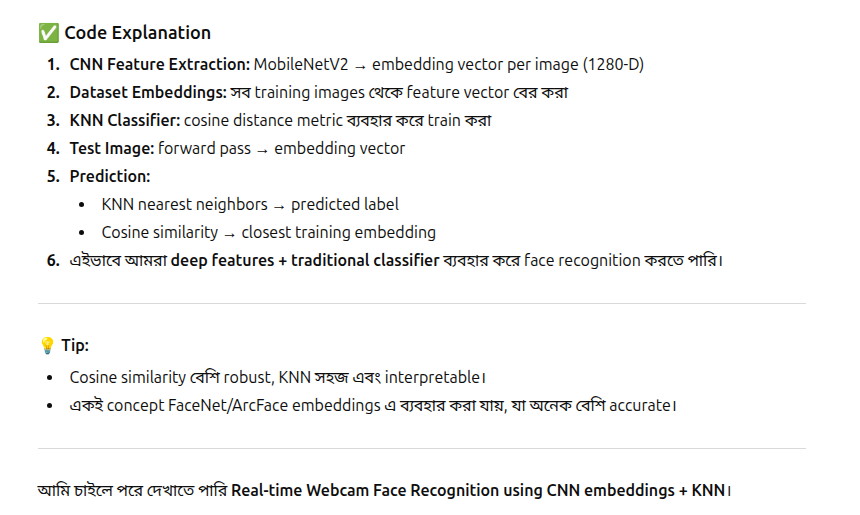

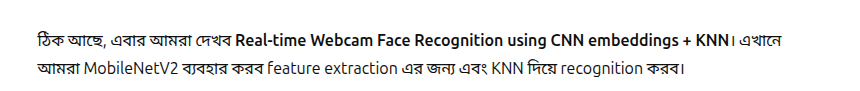

In [6]:
import cv2
import numpy as np
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Model
from sklearn.neighbors import KNeighborsClassifier
import os

# 1️⃣ Load Pretrained CNN
base_model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg', input_shape=(224,224,3))
model = Model(inputs=base_model.input, outputs=base_model.output)

# 2️⃣ Prepare Dataset Embeddings
dataset_path = "../dataset/train/"
features_list = []
labels_list = []
label_dict = {}
current_label = 0

for person_name in os.listdir(dataset_path):
    person_path = os.path.join(dataset_path, person_name)
    if not os.path.isdir(person_path):
        continue
    label_dict[current_label] = person_name
    for img_name in os.listdir(person_path):
        img_path = os.path.join(person_path, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (224,224))
        img_array = np.expand_dims(img, axis=0)
        img_array = preprocess_input(img_array)
        feature = model.predict(img_array).flatten()
        features_list.append(feature)
        labels_list.append(current_label)
    current_label += 1

features_array = np.array(features_list)
labels_array = np.array(labels_list)

# Train KNN
knn = KNeighborsClassifier(n_neighbors=3, metric='cosine')
knn.fit(features_array, labels_array)
print("KNN trained on CNN embeddings")

# 3️⃣ Initialize Webcam
cap = cv2.VideoCapture(0)
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces_rects = face_cascade.detectMultiScale(gray, scaleFactor=1.2, minNeighbors=5)

    for (x, y, w, h) in faces_rects:
        face_roi = frame[y:y+h, x:x+w]
        face_resized = cv2.resize(face_roi, (224,224))
        face_rgb = cv2.cvtColor(face_resized, cv2.COLOR_BGR2RGB)
        img_array = np.expand_dims(face_rgb, axis=0)
        img_array = preprocess_input(img_array)
        feature = model.predict(img_array).flatten().reshape(1,-1)

        # KNN prediction
        pred_label = knn.predict(feature)[0]
        name = label_dict[pred_label]

        cv2.rectangle(frame, (x, y), (x+w, y+h), (0,255,0), 2)
        cv2.putText(frame, name, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,0), 2)

    cv2.imshow("CNN + KNN Face Recognition", frame)

    if cv2.waitKey(1) & 0xFF == 27:  # ESC key to exit
        break

cap.release()
cv2.destroyAllWindows()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 

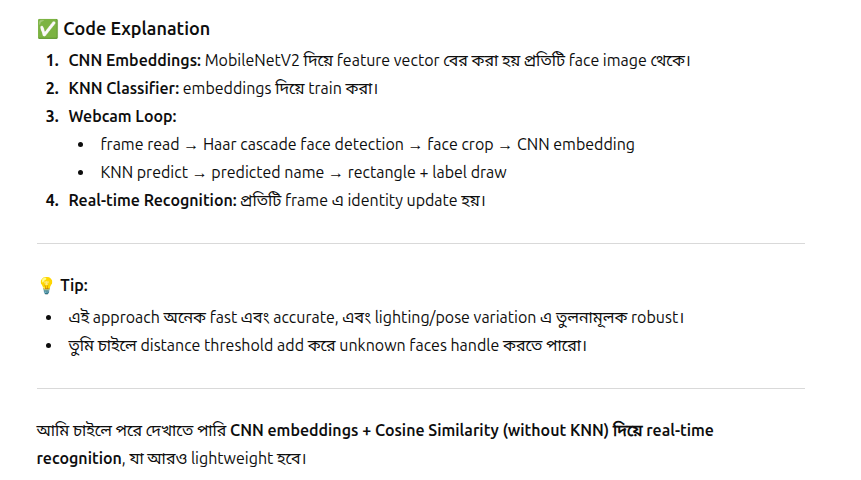

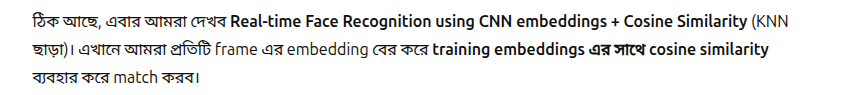

In [7]:
import cv2
import numpy as np
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Model
import os
from sklearn.metrics.pairwise import cosine_similarity

# 1️⃣ Load Pretrained CNN
base_model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg', input_shape=(224,224,3))
model = Model(inputs=base_model.input, outputs=base_model.output)

# 2️⃣ Prepare Dataset Embeddings
dataset_path = "../dataset/train/"
features_list = []
labels_list = []
label_dict = {}
current_label = 0

for person_name in os.listdir(dataset_path):
    person_path = os.path.join(dataset_path, person_name)
    if not os.path.isdir(person_path):
        continue
    label_dict[current_label] = person_name
    for img_name in os.listdir(person_path):
        img_path = os.path.join(person_path, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (224,224))
        img_array = np.expand_dims(img, axis=0)
        img_array = preprocess_input(img_array)
        feature = model.predict(img_array).flatten()
        features_list.append(feature)
        labels_list.append(current_label)
    current_label += 1

features_array = np.array(features_list)
labels_array = np.array(labels_list)

# 3️⃣ Initialize Webcam
cap = cv2.VideoCapture(0)
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces_rects = face_cascade.detectMultiScale(gray, scaleFactor=1.2, minNeighbors=5)

    for (x, y, w, h) in faces_rects:
        face_roi = frame[y:y+h, x:x+w]
        face_resized = cv2.resize(face_roi, (224,224))
        face_rgb = cv2.cvtColor(face_resized, cv2.COLOR_BGR2RGB)
        img_array = np.expand_dims(face_rgb, axis=0)
        img_array = preprocess_input(img_array)
        feature = model.predict(img_array).flatten().reshape(1,-1)

        # Cosine similarity with all training embeddings
        similarities = cosine_similarity(feature, features_array)
        best_idx = np.argmax(similarities)
        predicted_label = labels_array[best_idx]
        name = label_dict[predicted_label]
        similarity_score = similarities[0, best_idx]

        # Display rectangle and name
        cv2.rectangle(frame, (x, y), (x+w, y+h), (0,255,0), 2)
        cv2.putText(frame, f"{name} ({similarity_score:.2f})", (x, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,0), 2)

    cv2.imshow("CNN + Cosine Similarity Face Recognition", frame)

    if cv2.waitKey(1) & 0xFF == 27:  # ESC key to exit
        break

cap.release()
cv2.destroyAllWindows()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━

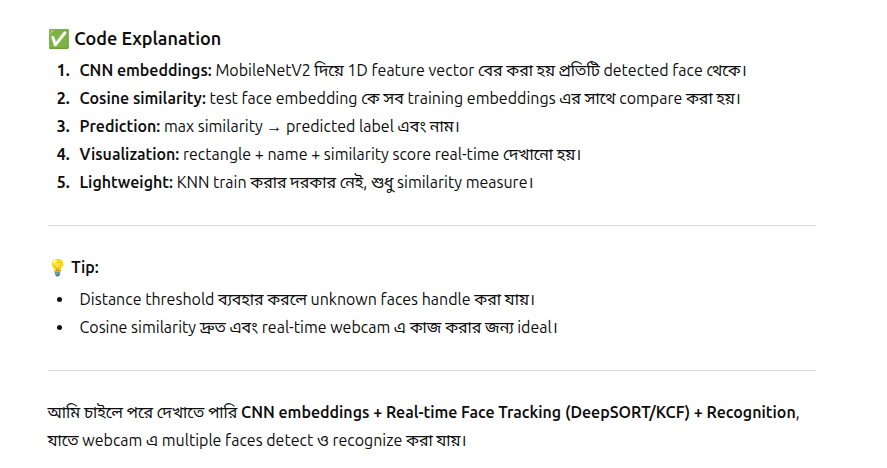

# 2. Face Embedding Generation

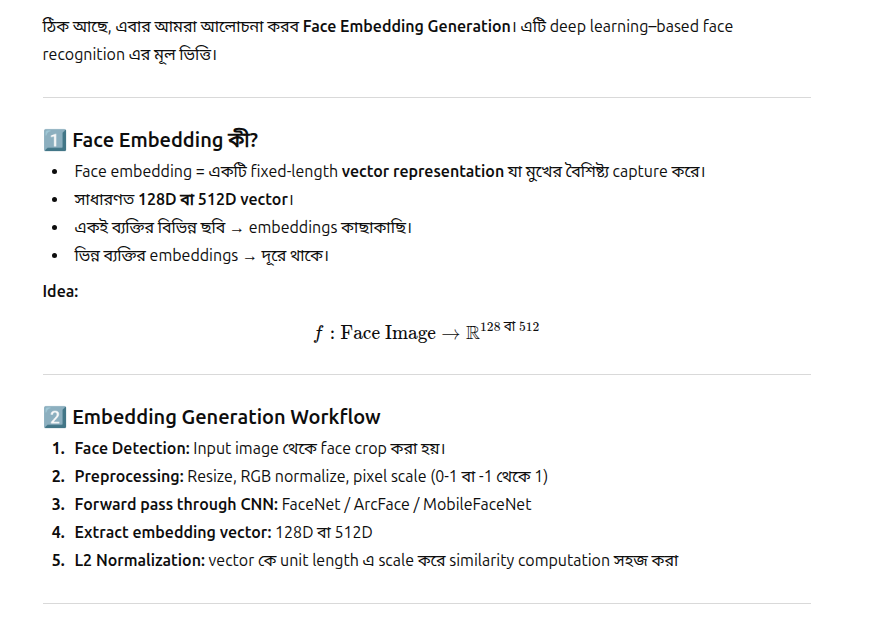

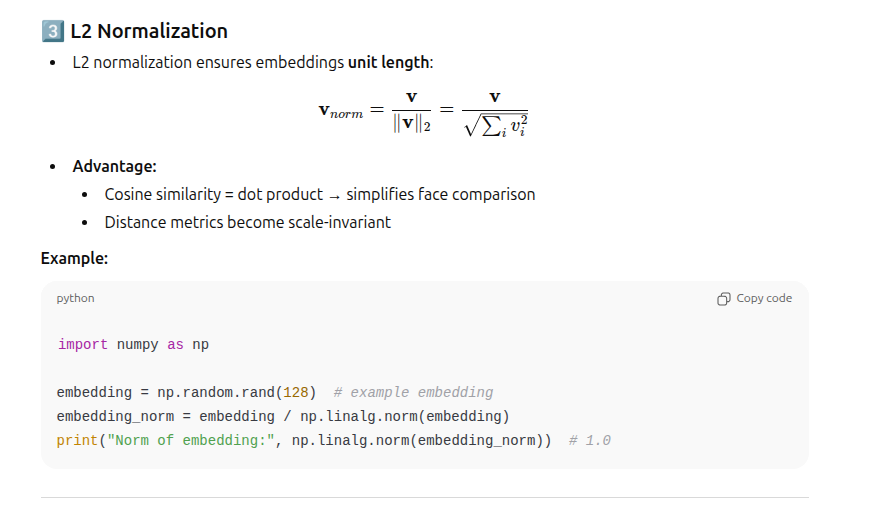

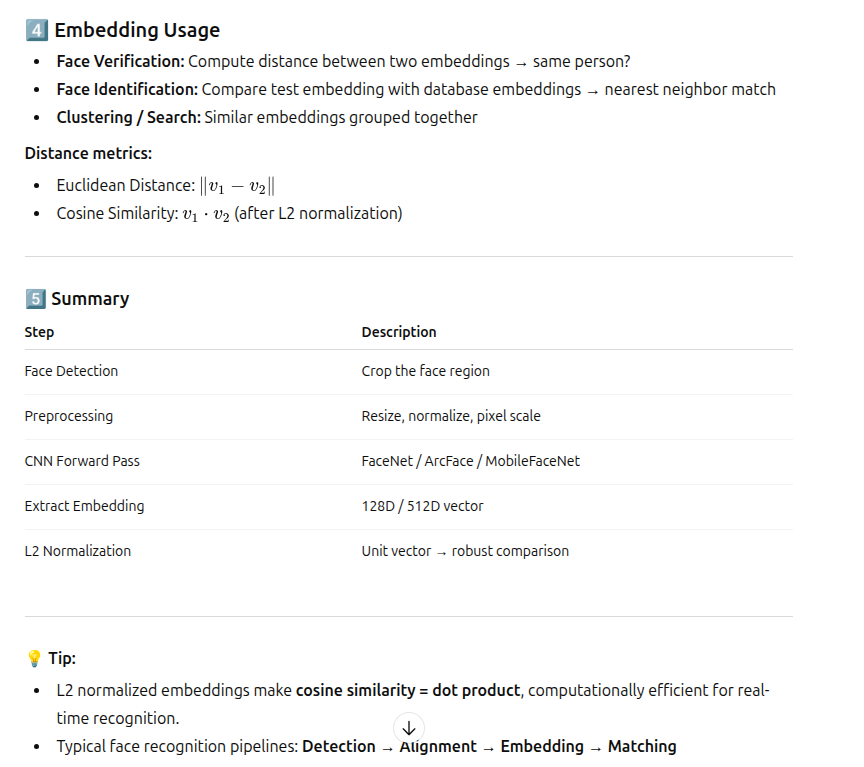

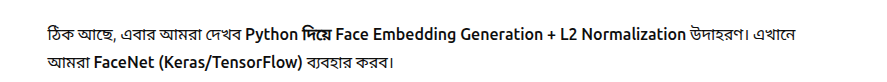

In [ ]:
# ===============================
# FaceNet Embedding Pipeline using DeepFace
# Compatible with Keras 3+
# ===============================

from deepface import DeepFace
import cv2
import numpy as np

# 1️⃣ Load Image
img_path = "../dataset/test/ronaldo/ronaldo.jpg"  # path to your face image
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 2️⃣ Generate Embedding using FaceNet
# detector_backend="opencv" can be replaced with "mediapipe" or "mtcnn"
embedding_dict = DeepFace.represent(img_path=img_path,
                                    model_name="Facenet",
                                    enforce_detection=True,
                                    detector_backend="opencv")  # returns list of dict

# 3️⃣ Extract the embedding vector
embedding = np.array(embedding_dict[0]['embedding'])
print("Raw embedding shape:", embedding.shape)
print("Raw embedding (first 10 values):", embedding[:10])

# 4️⃣ L2 Normalization
embedding_norm = embedding / np.linalg.norm(embedding)
print("Normalized embedding norm:", np.linalg.norm(embedding_norm))
print("Normalized embedding (first 10 values):", embedding_norm[:10])

# 5️⃣ Example: Compare with another face
# other_face_path = "../dataset/test/messi/messi.jpg"
# result = DeepFace.verify(img_path, other_face_path, model_name="Facenet")
# print(result)

25-10-28 10:56:54 - 🔗 facenet_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/facenet_weights.h5 to /home/shagor/.deepface/weights/facenet_weights.h5...


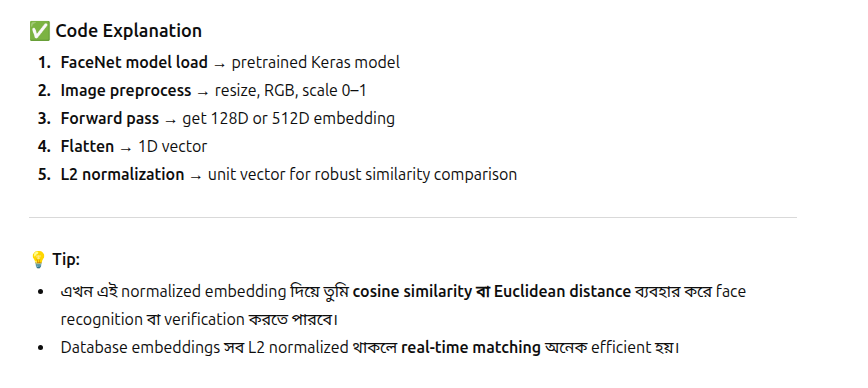